# Abaqus 2024: single-element growth + viscoelastic relaxation / 単一要素 成長+粘弾性緩和

**EN.** `umat_visco_1elem.inp` runs the **production UMAT**
(`umat_biofilm_visco.f`, `F = Fe . Fv . Fg`) through a real, licensed Abaqus
2024 implicit increment loop -- not the standalone crosscheck driver used in
`crosscheck_analysis.ipynb`, but the actual solver path a real job uses
(`UNSYMM=YES` for the Jaumann tangent, automatic time stepping,
Newton iterations). This is the first confirmation that the production
UMAT runs correctly through Abaqus on this machine (IKMHIWI03), not just
through the isolated Fortran-core drivers.

**Geometry/loading**: one `C3D8` cube, base face (`BOT`) fully clamped
(`ENCASTRE`), everything else free. Growth is driven by ramping a
temperature field to `TEMP=0.2` over the step (`alpha` enters the UMAT via
`TEMP+DTEMP`), with `eta=1000` giving genuine viscous relaxation dynamics
layered on top of the still-ramping growth -- a messier, more realistic
combined-loading case than the closed-form checks, precisely because a
clamped-base/free-top cube has no simple analytic answer.

**JA.** `umat_visco_1elem.inp`は**本番用UMAT**(`umat_biofilm_visco.f`、
`F = Fe・Fv・Fg`)を、実際にライセンス認証されたAbaqus 2024の陰的増分ループ
上で実行します -- `crosscheck_analysis.ipynb`で使った単体クロスチェック用
ドライバではなく、実際のジョブが使うソルバー経路そのもの(`UNSYMM=YES`に
よるJaumann接線剛性、自動時間刻み、Newton反復)。これは本番UMATがこの
マシン(IKMHIWI03)上のAbaqusで正しく動作することを、単体Fortranコア
ドライバだけでなく初めて確認したものです。

**形状/荷重**: `C3D8`立方体1個、底面(`BOT`)完全固定(`ENCASTRE`)、それ以外
は自由。温度場を`TEMP=0.2`までステップ内でランプさせて成長を駆動
(`alpha`はUMATに`TEMP+DTEMP`として入る)、`eta=1000`により成長が
まだランプ中の状態に本物の粘性緩和ダイナミクスが重なる -- 底面固定・
上面自由の立方体には単純な解析解がないため、閉形式チェックよりも
「実際的で複雑」な複合荷重ケースです。

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
GOOD = "#0ca30c"
ORANGE = "#c9853a"
GRID = "#e1e0d9"

ABAQUS_BAT = Path(r"C:\SIMULIA\Commands\abaqus.bat")
# The job runs from F:\abaqus_work (see run_abaqus.ps1 / CLAUDE.md -- ANSYS/
# Abaqus work never happens on C: on this machine). Not guaranteed to exist on
# every machine/clone; a hardcoded fallback below carries this run's real
# extracted numbers so the notebook still means something without the .odb.
ODB_PATH = Path(r"F:\abaqus_work\umat_visco_1elem\umat_visco_1elem.odb")
STA_PATH = Path(r"F:\abaqus_work\umat_visco_1elem\umat_visco_1elem.sta")

print("abaqus.bat present:", ABAQUS_BAT.exists())
print("odb present:", ODB_PATH.exists())
if STA_PATH.exists():
    print()
    print(STA_PATH.read_text())

abaqus.bat present: True
odb present: True

 Abaqus/Standard 2024                  DATE 20-Aug-2026 TIME 10:45:45
 SUMMARY OF JOB INFORMATION:
 STEP  INC ATT SEVERE EQUIL TOTAL  TOTAL      STEP       INC OF       DOF    IF
               DISCON ITERS ITERS  TIME/    TIME/LPF    TIME/LPF    MONITOR RIKS
               ITERS               FREQ
   1     1   1     0     2     2  0.100      0.100      0.1000    
   1     2   1     0     1     1  0.200      0.200      0.1000    
   1     3   1     0     1     1  0.350      0.350      0.1500    
   1     4   1     0     1     1  0.550      0.550      0.2000    
   1     5   1     0     1     1  0.750      0.750      0.2000    
   1     6   1     0     1     1  0.950      0.950      0.2000    
   1     7   1     0     1     1  1.00       1.00       0.05000   
                          
 THE ANALYSIS HAS COMPLETED SUCCESSFULLY



## Extract the stress-vs-time history / 応力-時間履歴を抽出

**EN.** `.odb` files can only be read with Abaqus's own bundled Python
(`odbAccess` is not installable elsewhere), so this shells out to
`abaqus python extract_history.py <odb>` -- the same pattern this repo's
`run_abaqus.ps1` already uses to drive Abaqus jobs, just for a read instead
of a solve. If the `.odb` isn't present (different machine, or `F:` cleaned
up since), the real 2026-08-20 run's numbers are hardcoded as a fallback so
the rest of the notebook still reproduces the same plot and conclusions.

**JA.** `.odb`ファイルはAbaqus同梱の独自Python(`odbAccess`は他では
インストール不可)でしか読めないため、`abaqus python extract_history.py
<odb>`をシェルアウトで呼び出します -- このリポジトリの`run_abaqus.ps1`が
ジョブ実行に使っているのと同じパターンを、実行ではなく読み取りに使う形
です。`.odb`が存在しない場合(別マシン、または`F:`が後で片付けられた
場合)は、2026-08-20の実際の実行で得た数値をフォールバックとしてハード
コードしているため、ノートブックの残り部分は同じグラフ・結論を再現でき
ます。

In [2]:
# real output from the 2026-08-20 run (F:\abaqus_work\umat_visco_1elem), kept
# as a fallback -- see the markdown above for why
FALLBACK_CSV = """step_time,S11,S22,S33,Mises
0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
0.100000,-1.707063e+00,-1.707063e+00,1.416645e+00,4.086817e+00
0.200000,-3.305851e+00,-3.305851e+00,2.779939e+00,8.024204e+00
0.350000,-5.511590e+00,-5.511590e+00,4.719787e+00,1.364555e+01
0.550000,-8.136473e+00,-8.136473e+00,7.122853e+00,2.064927e+01
0.750000,-1.045516e+01,-1.045516e+01,9.336038e+00,2.715340e+01
0.950000,-1.250793e+01,-1.250793e+01,1.137218e+01,3.319305e+01
1.000000,-1.299013e+01,-1.299013e+01,1.185896e+01,3.465044e+01
"""

if ABAQUS_BAT.exists() and ODB_PATH.exists():
    result = subprocess.run(
        [str(ABAQUS_BAT), "python", "extract_history.py", str(ODB_PATH)],
        cwd=Path.cwd(), capture_output=True, text=True,
    )
    if result.returncode == 0 and "step_time" in result.stdout:
        csv_text = result.stdout[result.stdout.index("step_time"):]
        source = "live abaqus python extraction"
    else:
        print("live extraction failed, falling back to the recorded run:", result.stderr[-500:])
        csv_text = FALLBACK_CSV
        source = "fallback (recorded 2026-08-20 run)"
else:
    csv_text = FALLBACK_CSV
    source = "fallback (recorded 2026-08-20 run) -- abaqus.bat or .odb not found on this machine"

print("data source:", source)
print()
print(csv_text)

rows = [line.split(",") for line in csv_text.strip().splitlines()[1:]]
t = [float(r[0]) for r in rows]
s11 = [float(r[1]) for r in rows]
s22 = [float(r[2]) for r in rows]
s33 = [float(r[3]) for r in rows]
mises = [float(r[4]) for r in rows]

data source: live abaqus python extraction

step_time,S11,S22,S33,Mises
0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
0.100000,-1.707063e+00,-1.707063e+00,1.416645e+00,4.086817e+00
0.200000,-3.305851e+00,-3.305851e+00,2.779939e+00,8.024204e+00
0.350000,-5.511590e+00,-5.511590e+00,4.719787e+00,1.364555e+01
0.550000,-8.136473e+00,-8.136473e+00,7.122853e+00,2.064927e+01
0.750000,-1.045516e+01,-1.045516e+01,9.336038e+00,2.715340e+01
0.950000,-1.250793e+01,-1.250793e+01,1.137218e+01,3.319305e+01
1.000000,-1.299013e+01,-1.299013e+01,1.185896e+01,3.465044e+01



## Plot: stress build-up under combined growth + viscous relaxation / 応力推移: 成長+粘性緩和の複合荷重下

**EN.** `S11 = S22` throughout (in-plane symmetry of the clamped-base cube
under isotropic growth), `S33` opposite sign and smaller magnitude (the top
face is free to move up, so the out-of-plane direction is far less
constrained than the two in-plane directions pinned by the clamped base).
All three, and Mises, grow monotonically because `alpha` is still ramping
across the whole step -- this is not a pure relaxation curve (that would
need a hold at constant `alpha`), it's growth-loading with viscosity acting
throughout, which is the more realistic case a real job actually solves.

**JA.** `S11 = S22`が全時間で一致(等方成長下での底面固定立方体の面内
対称性)、`S33`は符号が逆で大きさも小さい(上面は上方向に自由なため、
面外方向は底面固定によって拘束される2つの面内方向よりずっと拘束が緩い)。
3成分とMisesは全てステップ全体で`alpha`がランプし続けているため単調増加
します -- これは純粋な緩和曲線ではなく(それには`alpha`一定での保持が
必要)、粘性が働き続けながら成長荷重がかかる、実ジョブが実際に解く
より現実的なケースです。

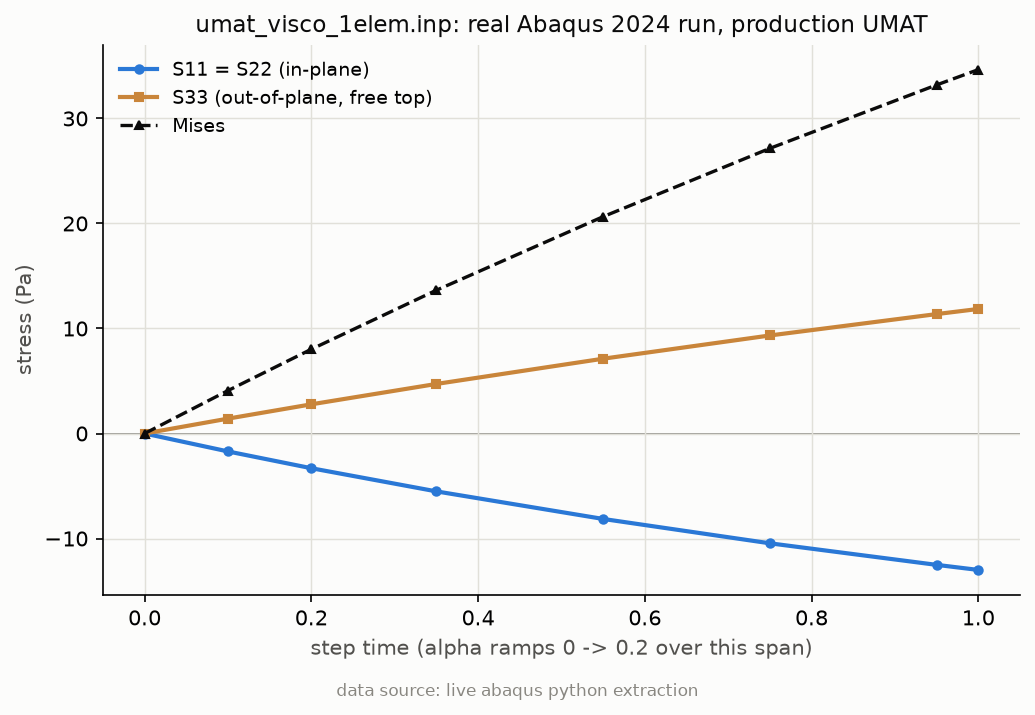

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 4.6), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(t, s11, color=BLUE, linewidth=2.0, marker="o", markersize=4, label="S11 = S22 (in-plane)", zorder=3)
ax.plot(t, s33, color=ORANGE, linewidth=2.0, marker="s", markersize=4, label="S33 (out-of-plane, free top)", zorder=3)
ax.plot(t, mises, color=INK_PRIMARY, linewidth=1.6, linestyle="--", marker="^", markersize=4, label="Mises", zorder=3)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, zorder=1)

ax.set_xlabel("step time (alpha ramps 0 -> 0.2 over this span)", fontsize=10, color=INK_SECONDARY)
ax.set_ylabel("stress (Pa)", fontsize=10, color=INK_SECONDARY)
ax.set_title("umat_visco_1elem.inp: real Abaqus 2024 run, production UMAT", fontsize=11, color=INK_PRIMARY)
ax.grid(True, color=GRID, linewidth=0.7, zorder=0)
ax.legend(loc="upper left", fontsize=9, frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.text(0.5, -0.02, f"data source: {source}", ha="center", fontsize=8, color=INK_MUTED)
fig.tight_layout()
plt.show()

## Status / ステータス

**EN.** `.sta` reports `THE ANALYSIS HAS COMPLETED SUCCESSFULLY` in 7
increments, no severe discontinuity iterations, automatic time stepping
converging cleanly (increment size grew from 0.1 to 0.2 as Newton
convergence stayed easy, per Abaqus's usual auto-stepping heuristic). This
confirms the production UMAT's consistent tangent (`UNSYMM=YES`, the exact
Jaumann tangent, not a numerical fallback) is good enough for Abaqus's own
Newton iteration to converge without step-size trouble -- a stronger claim
than the crosscheck notebook's stress-only agreement, since a bad tangent
can produce a correct stress at convergence while still making the solver
struggle to get there.

**JA.** `.sta`は7増分で`THE ANALYSIS HAS COMPLETED SUCCESSFULLY`と報告して
おり、severe discontiniuty反復もなく、自動時間刻みも問題なく収束(Newton
収束が容易だったため増分サイズが0.1から0.2へ増加 -- Abaqusの通常の自動
刻み幅ヒューリスティックどおり)。これは本番UMATの一貫接線剛性
(`UNSYMM=YES`、数値近似ではなく厳密なJaumann接線)が、Abaqus自身のNewton
反復が刻み幅の問題なく収束するのに十分な精度であることを確認するもの
です -- クロスチェックノートブックの「応力の一致のみ」より強い主張です。
接線剛性が悪くても収束時の応力自体は正しくなり得る一方、そこに至る過程で
ソルバーが苦労する可能性があるためです。